In [1]:
# ================= RESET =================
import tensorflow as tf
tf.keras.backend.clear_session()
tf.keras.backend.set_image_data_format("channels_last")

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight


In [2]:
# config

DATASET_DIR = r"C:\Users\HP\Documents\Major_Final\Github-code\Module-2_Mini-2\Images_Data"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-5


In [3]:
# data loading

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 7719 images belonging to 8 classes.
Found 1926 images belonging to 8 classes.


In [4]:
# class weights

y_train = train_gen.classes

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight = dict(enumerate(class_weights))


In [5]:
# model finetune

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# TRUE fine-tuning
base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
outputs = Dense(train_gen.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 24,061,192 (91.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [8]:
# training and saving best model

checkpoint = ModelCheckpoint(
    "best_resnet50_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.2864 - loss: 2.0243
Epoch 1: val_loss improved from None to 2.62394, saving model to best_resnet50_model.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 2268s 9s/step - accuracy: 0.4324 - loss: 1.6899 - val_accuracy: 0.0675 - val_loss: 2.6239
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.6858 - loss: 1.2016
Epoch 2: val_loss improved from 2.62394 to 2.14383, saving model to best_resnet50_model.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 2528s 10s/step - accuracy: 0.7118 - loss: 1.1411 - val_accuracy: 0.2529 - val_loss: 2.1438
Epoch 3/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7755 - loss: 1.0019
Epoch 3: val_loss improved from 2.14383 to 1.47353, saving model to best_resnet50_model.keras
242/242 ━━━━━━━━━━━━━━━━━━━━ 2449s 10s/step - accuracy: 0.7894 - loss: 0.9810 - val_accuracy: 0.5852 - val_loss: 1.4735
Epoch 4/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.8257 - loss: 0.9098
Epoch 4: val_loss imp

In [13]:
# save final model

model.save("resnet50_disaster_finetuned.keras")


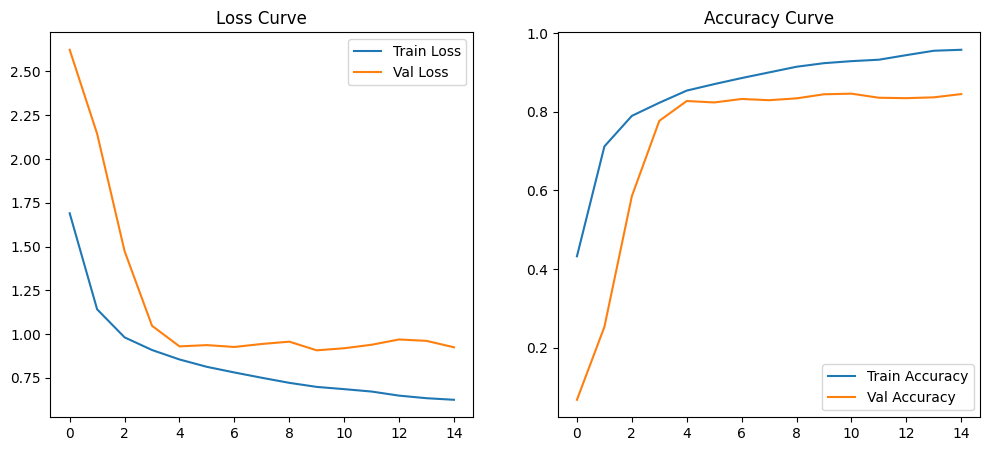

In [10]:
# training and validation curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()


61/61 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step


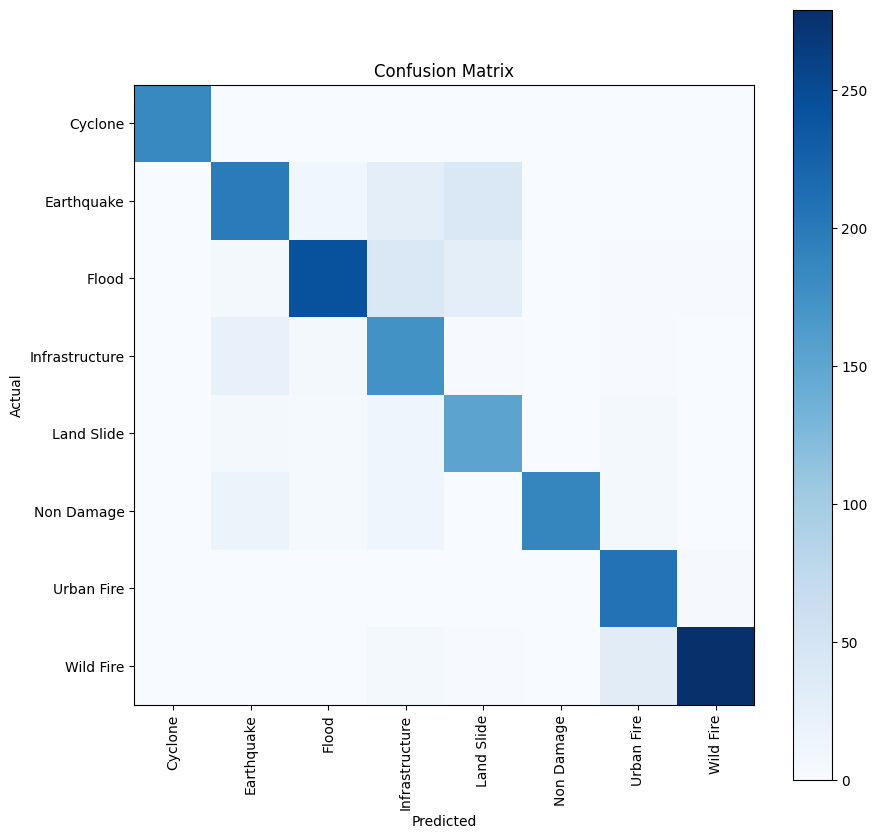

In [11]:
# confusion matrix

val_gen.reset()
y_true = val_gen.classes
y_pred = np.argmax(model.predict(val_gen), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,10))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(val_gen.class_indices)), val_gen.class_indices.keys(), rotation=90)
plt.yticks(range(len(val_gen.class_indices)), val_gen.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


<Figure size 1000x1000 with 0 Axes>

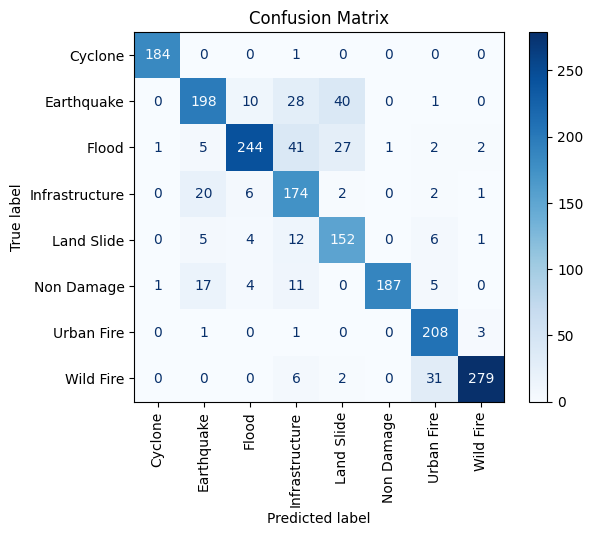

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_gen.class_indices.keys()
)

plt.figure(figsize=(10,10))
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()


In [12]:
# classification report

print(classification_report(
    y_true,
    y_pred,
    target_names=list(val_gen.class_indices.keys()),
    digits=4
))


                precision    recall  f1-score   support

       Cyclone     0.9892    0.9946    0.9919       185
    Earthquake     0.8049    0.7148    0.7572       277
         Flood     0.9104    0.7554    0.8257       323
Infrastructure     0.6350    0.8488    0.7265       205
    Land Slide     0.6816    0.8444    0.7543       180
    Non Damage     0.9947    0.8311    0.9056       225
    Urban Fire     0.8157    0.9765    0.8889       213
     Wild Fire     0.9755    0.8774    0.9238       318

      accuracy                         0.8442      1926
     macro avg     0.8509    0.8554    0.8467      1926
  weighted avg     0.8622    0.8442    0.8471      1926



In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="macro")
recall    = recall_score(y_true, y_pred, average="macro")
f1        = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy       : {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1-score : {f1:.4f}")


Accuracy       : 0.8442
Macro Precision: 0.8509
Macro Recall   : 0.8554
Macro F1-score : 0.8467
